In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import DataLoader, Dataset

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
df = pd.read_csv("Electric_Production.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE")

data = df["Value"].values.reshape(-1, 1)

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [19]:
# PARAMETER CALCULATION BASED ON ROLL NUMBER
# Roll Number: 102317272

# Step 1: Calculate window_size
# Rule: window_size = (sum of all digits) % 10 + 8

# Digits in roll number = 1, 0, 2, 3, 1, 7, 2, 7, 2
# Sum = 1 + 0 + 2 + 3 + 1 + 7 + 2 + 7 + 2 = 25

# Apply formula:
# window_size = 25 % 10 + 8
#              = 5 + 8
#              = 13

# ------------------------------------------------------------

# Step 2: Calculate prediction_horizon
# Rule: prediction_horizon = (last 2 digits) % 3 + 1

# Last 2 digits = 72

# Apply formula:
# prediction_horizon = 72 % 3 + 1
#                    = 0 + 1
#                    = 1


# ------------------------------------------------------------

# Step 3: Calculate hidden_size
# Rule: hidden_size = (first 3 digits) % 16 + 8

# First 3 digits = 102

# Apply formula:
# hidden_size = 102 % 16 + 8
#             = 6 + 8
#             = 14

In [ ]:
window_size = 13
horizon = 1
hidden_size = 14
batch_size = 32
epochs = 20

In [ ]:
# -------------------- Create Sequences --------------------
def create_sequences(data, window, horizon):
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i:i+window])
        y.append(data[i+window+horizon-1])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window_size, horizon)

In [ ]:
# -------------------- Train/Test Split --------------------
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# -------------------- Dataset --------------------
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(SeqDataset(X_test, y_test), batch_size=batch_size)

In [ ]:
# -------------------- Models --------------------
class GRUModel(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.gru = nn.GRU(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TransformerModel(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.input_layer = nn.Linear(1, hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=2,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

In [ ]:
# -------------------- Train Function --------------------
def train_model(model):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss / len(train_loader))

    return losses

In [ ]:
# -------------------- Evaluation --------------------
def evaluate(model):
    model.eval()
    preds, actual = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch).cpu().numpy()

            preds.extend(pred)
            actual.extend(y_batch.numpy())

    preds = scaler.inverse_transform(preds)
    actual = scaler.inverse_transform(actual)

    mse = mean_squared_error(actual, preds)
    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mse)

    return mse, mae, rmse, actual, preds

In [ ]:
# -------------------- Run Models --------------------
models = {
    "GRU": GRUModel(hidden_size),
    "LSTM": LSTMModel(hidden_size),
    "Transformer": TransformerModel(hidden_size)
}

histories = {}
predictions = {}
actual_values = None
results = []

for name, model in models.items():
    print(f"Training {name}...")

    loss = train_model(model)
    mse, mae, rmse, actual, preds = evaluate(model)

    histories[name] = loss
    predictions[name] = preds
    actual_values = actual

    results.append([name, mse, mae, rmse])

Training GRU...
Training LSTM...
Training Transformer...


In [ ]:
# -------------------- Results Table --------------------
results_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "RMSE"])
results_df = results_df.sort_values("RMSE")

print("\nFinal Results:\n", results_df)


Final Results:
          Model         MSE        MAE       RMSE
1         LSTM   88.282118   7.952014   9.395856
2  Transformer   90.783593   7.954563   9.528042
0          GRU  182.874103  10.587514  13.523095


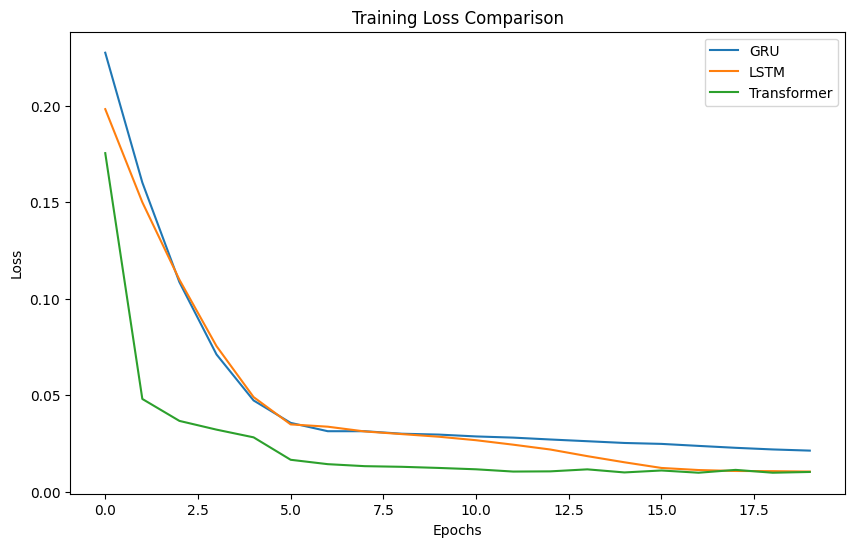

In [ ]:
# -------------------- LOSS PLOT --------------------
plt.figure(figsize=(10,6))

for name, loss in histories.items():
    plt.plot(loss, label=name)

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

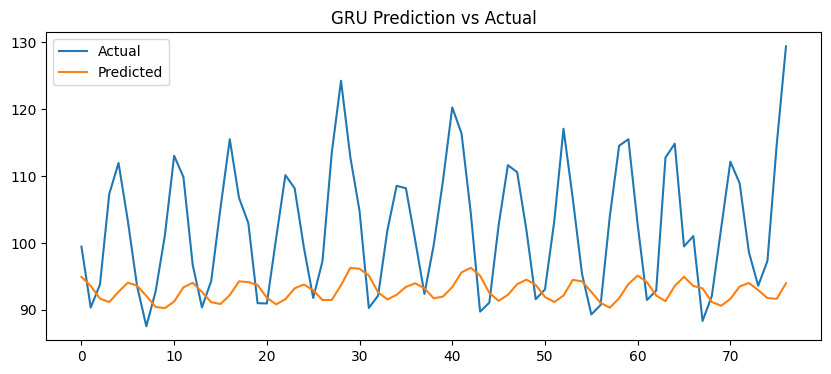

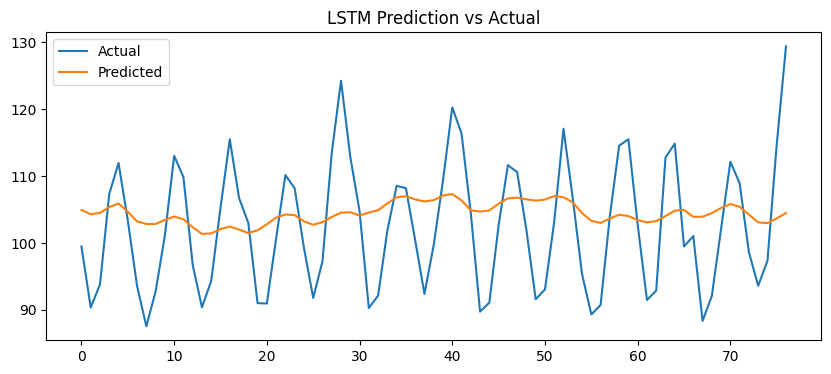

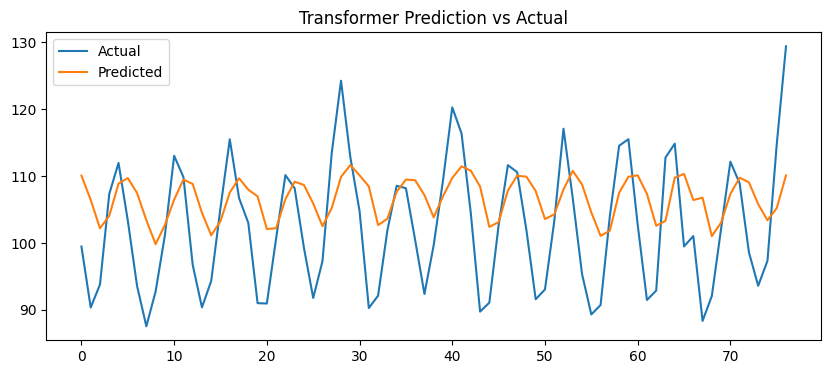

In [ ]:
# -------------------- PREDICTION PLOTS --------------------
for name, preds in predictions.items():
    plt.figure(figsize=(10,4))

    plt.plot(actual_values, label="Actual")
    plt.plot(preds, label="Predicted")

    plt.title(f"{name} Prediction vs Actual")
    plt.legend()
    plt.show()